C:\Users\DELL\AppData\Local\Temp\ipykernel_8916\3271795868.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dates"] = pd.to_datetime(df["Dates"])


Input Date in YYYY-MM-DD Format:  2025-05-06


Estimated price on 2025-05-06: 12.30


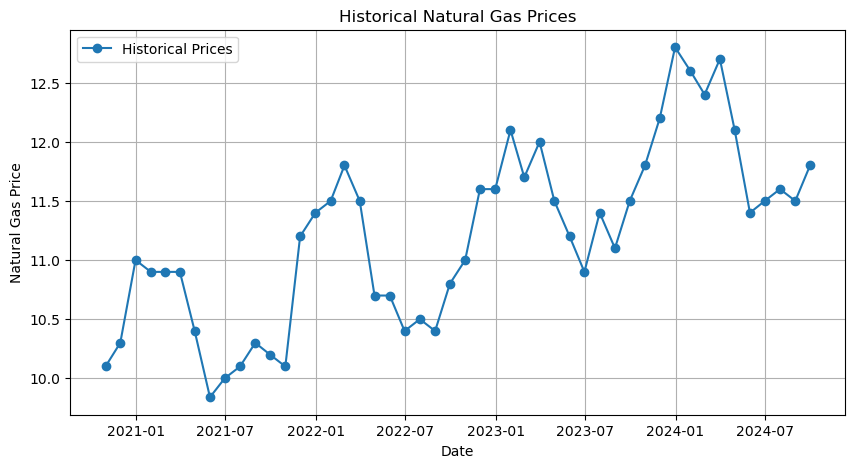

C:\Users\DELL\AppData\Local\Temp\ipykernel_8916\3271795868.py:86: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


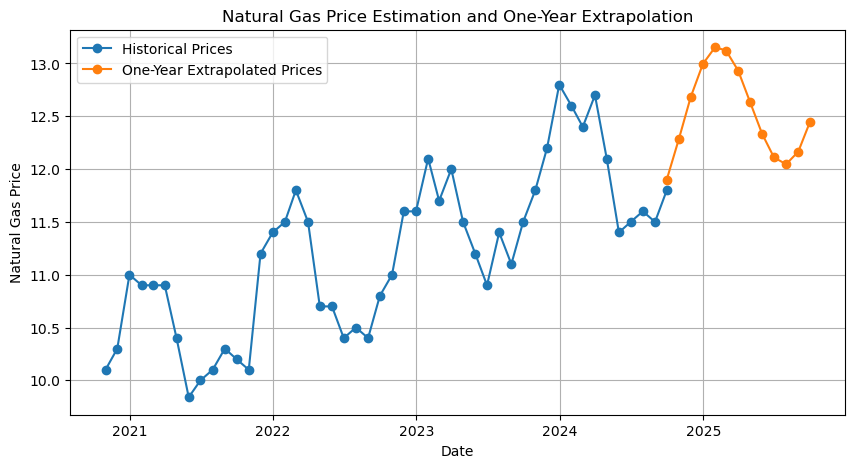

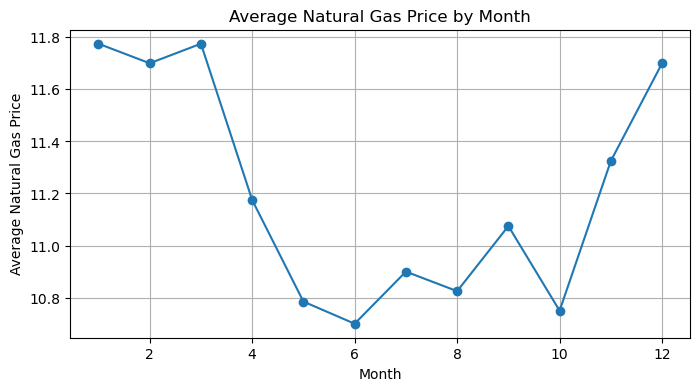

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


# -----------------------------
# Load and prepare data
# -----------------------------
df = pd.read_csv("Nat_Gas.csv")

df["Dates"] = pd.to_datetime(df["Dates"])
df = df.sort_values("Dates").reset_index(drop=True)

start_date = df["Dates"].min()

df["Days"] = (df["Dates"] - start_date).dt.days
df["Month"] = df["Dates"].dt.month

# Cyclical month encoding to capture seasonality
df["Sin_Month"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Cos_Month"] = np.cos(2 * np.pi * df["Month"] / 12)


# -----------------------------
# Train regression model
# -----------------------------
X = df[["Days", "Sin_Month", "Cos_Month"]]
y = df["Prices"]

model = LinearRegression()
model.fit(X, y)


# -----------------------------
# Price estimation function
# -----------------------------
def estimate_price(date_input):
    date_input = pd.to_datetime(date_input)

    day_input = (date_input - start_date).days
    month_input = date_input.month

    # If date is within historical data range, use interpolation
    if df["Days"].min() <= day_input <= df["Days"].max():
        price = np.interp(day_input, df["Days"], df["Prices"])
        return float(price)

    # If date is outside historical range, use regression extrapolation
    input_features = pd.DataFrame({
        "Days": [day_input],
        "Sin_Month": [np.sin(2 * np.pi * month_input / 12)],
        "Cos_Month": [np.cos(2 * np.pi * month_input / 12)]
    })

    predicted_price = model.predict(input_features)[0]
    return float(predicted_price)


# -----------------------------
# Example custom date input
# -----------------------------
date_input = input("Input Date in YYYY-MM-DD Format: ")

final_estimated_price = estimate_price(date_input)

print(f"Estimated price on {date_input}: {final_estimated_price:.2f}")


# -----------------------------
# Visualize historical data
# -----------------------------
plt.figure(figsize=(10, 5))
plt.plot(df["Dates"], df["Prices"], marker="o", label="Historical Prices")
plt.xlabel("Date")
plt.ylabel("Natural Gas Price")
plt.title("Historical Natural Gas Prices")
plt.grid(True)
plt.legend()
plt.show()


# -----------------------------
# Extrapolate one year into future
# -----------------------------
future_dates = pd.date_range(
    start=df["Dates"].max(),
    end=df["Dates"].max() + pd.DateOffset(years=1),
    freq="M"
)

future_df = pd.DataFrame({"Dates": future_dates})
future_df["Days"] = (future_df["Dates"] - start_date).dt.days
future_df["Month"] = future_df["Dates"].dt.month
future_df["Sin_Month"] = np.sin(2 * np.pi * future_df["Month"] / 12)
future_df["Cos_Month"] = np.cos(2 * np.pi * future_df["Month"] / 12)

future_df["Estimated_Prices"] = model.predict(
    future_df[["Days", "Sin_Month", "Cos_Month"]]
)


# -----------------------------
# Visualize historical + future prices
# -----------------------------
plt.figure(figsize=(10, 5))
plt.plot(df["Dates"], df["Prices"], marker="o", label="Historical Prices")
plt.plot(future_df["Dates"], future_df["Estimated_Prices"], marker="o", label="One-Year Extrapolated Prices")
plt.xlabel("Date")
plt.ylabel("Natural Gas Price")
plt.title("Natural Gas Price Estimation and One-Year Extrapolation")
plt.grid(True)
plt.legend()
plt.show()


# -----------------------------
# Check seasonal pattern by month
# -----------------------------
monthly_avg = df.groupby("Month")["Prices"].mean()

plt.figure(figsize=(8, 4))
plt.plot(monthly_avg.index, monthly_avg.values, marker="o")
plt.xlabel("Month")
plt.ylabel("Average Natural Gas Price")
plt.title("Average Natural Gas Price by Month")
plt.grid(True)
plt.show()